#ANN Densa para reconocimiento de imagenes
(Sin Convoluciones)

Este código utiliza TensorFlow y TensorFlow Datasets para cargar el conjunto de datos MNIST, que consiste en imágenes de dígitos escritos a mano junto con sus etiquetas correspondientes. A continuación, normaliza los datos dividiendo los valores de píxeles de las imágenes (que van de 0 a 255) por 255, para que estén en el rango de 0 a 1. Esto ayuda al modelo de red neuronal a aprender de manera más efectiva y rápida.

Después de la normalización, los datos se almacenan en variables separadas para entrenamiento y pruebas. Además, se agrega caché a los datos de entrenamiento y pruebas, lo que significa que se almacenan en la memoria para un acceso más rápido durante el entrenamiento.

Por último, define una lista de clases que corresponde a los dígitos del 0 al 9, que se utilizará más adelante, probablemente para la salida del modelo de red neuronal, donde cada neurona de salida representará una clase específica.

In [ ]:
!python -V

Python 3.12.11


In [ ]:
!pip list |grep tensor

pytensor                              2.31.7
safetensors                           0.6.2
tensorboard                           2.19.0
tensorboard-data-server               0.7.2
tensorflow                            2.19.0
tensorflow-datasets                   4.9.9
tensorflow_decision_forests           1.12.0
tensorflow-hub                        0.16.1
tensorflow-metadata                   1.17.2
tensorflow-probability                0.25.0
tensorflow-text                       2.19.0
tensorstore                           0.1.76


In [ ]:

import tensorflow as tf
import tensorflow_datasets as tfds
import os

print(tf.__version__)

2.19.0


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
#Descargar set de datos de MNIST (Numeros escritos a mano, etiquetados)
#https://www.tensorflow.org/datasets/catalog/overview?hl=es-419
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.JCA79N_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.JCA79N_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:
metadatos

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

In [ ]:
#Obtener en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [ ]:
datos_entrenamiento

<_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
#Funcion de normalizacion para los datos (Pasar valor de los pixeles de 0-255 a 0-1)
#(Hace que la red aprenda mejor y mas rapido)
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 #Aqui se pasa de 0-255 a 0-1
  return imagenes, etiquetas

#Normalizar los datos de entrenamiento con la funcion que hicimos
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#Agregar a cache (usar memoria en lugar de disco, entrenamiento mas rapido)
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

clases = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

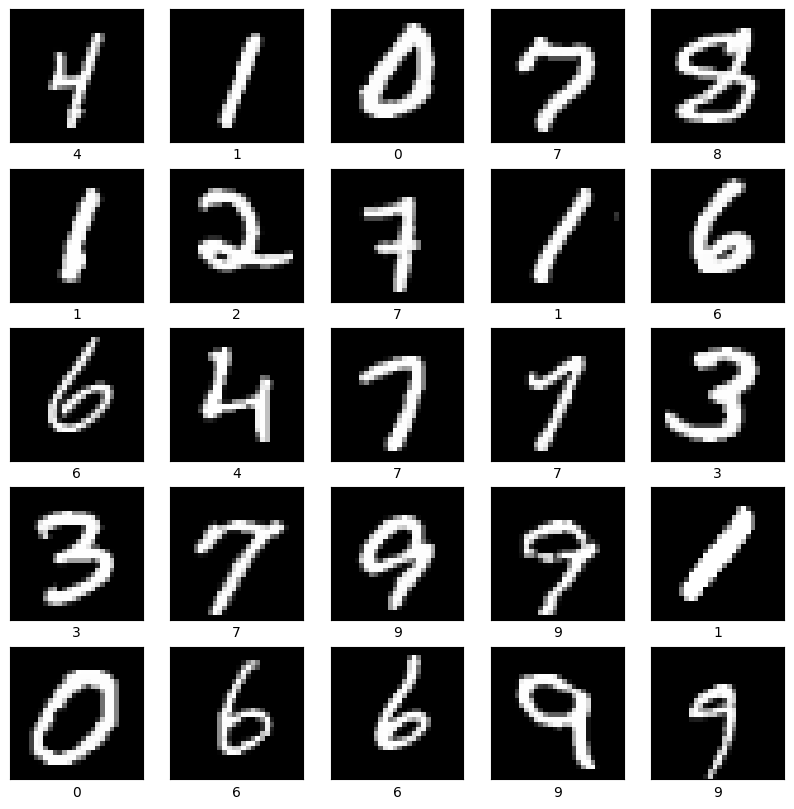

In [ ]:
#Codigo para mostrar imagenes del set, no es necesario ejecutarlo, solo imprime unos numeros :)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  imagen = imagen.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary_r)
  plt.xlabel(clases[etiqueta])

plt.show()

**tf.keras.layers.Flatten()**

es una capa de Keras que transforma un tensor multidimensional en un vector unidimensional. Su principal función es "aplanar" la entrada, lo que es especialmente útil en redes neuronales, donde los datos de entrada suelen ser imágenes o volúmenes de datos que necesitan ser convertidos en un formato adecuado para ser procesados por capas densas (fully connected layers).

Ejemplo:

Ejemplo de Uso
Imagina que tienes una imagen de 28x28 píxeles (como en el conjunto de datos MNIST). Esta imagen se representaría como un tensor de forma (28, 28, 1) (donde 1 indica que es en escala de grises). Cuando pasas esta imagen a través de la capa Flatten, el resultado será un vector de 784 elementos (28 * 28).

Orginal
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]

Flatten
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]


In [ ]:
#Crear el modelo (Modelo denso, regular, sin redes convolucionales todavia)
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),  # Define la entrada
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

#Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
#Los numeros de datos de entrenamiento y pruebas 60k y 10k)
num_datos_entrenamiento = metadatos.splits["train"].num_examples
num_datos_pruebas = metadatos.splits["test"].num_examples
num_datos_entrenamiento,num_datos_pruebas

(60000, 10000)

**metadatos:** Este objeto contiene información sobre el conjunto de datos, incluida la cantidad de ejemplos, las características de los datos, y más.


**splits:** Esta propiedad se refiere a las divisiones del conjunto de datos. Por lo general, los conjuntos de datos están divididos en diferentes partes, como "train" (entrenamiento), "test" (pruebas) y a veces "validation" (validación).


["train"]: Accede a la división de entrenamiento del conjunto de datos.


**num_examples:** Este atributo devuelve el número total de ejemplos en la división especificada (en este caso, el conjunto de entrenamiento).

In [ ]:

#Trabajar por lotes
TAMANO_LOTE=32

**repeat():**E sta función hace que el conjunto de datos se repita indefinidamente. Esto es útil durante el entrenamiento porque permite que el modelo pase por los mismos datos varias veces sin tener que volver a cargar el conjunto de datos.

**shuffle(num_datos_entrenamiento):** Esta función mezcla aleatoriamente los datos. El argumento num_datos_entrenamiento establece el tamaño del buffer que se utilizará para mezclar los datos. Al usar este valor, se asegura de que todos los datos se incluyan en la mezcla, lo que ayuda a evitar que el modelo aprenda patrones indeseados en el orden de los datos.

**batch(TAMANO_LOTE):** Esta función agrupa los ejemplos en lotes del tamaño especificado por TAMANO_LOTE. El uso de lotes en el entrenamiento permite que el modelo procese múltiples ejemplos a la vez, lo que puede mejorar la eficiencia del entrenamiento.

In [ ]:
#Shuffle y repeat hacen que los datos esten mezclados de manera aleatoria
#para que el entrenamiento no se aprenda las cosas en orden
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_datos_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

**from tensorflow.keras.callbacks import EarlyStopping:** Esta línea importa la clase EarlyStopping de la biblioteca Keras. Los callbacks son funciones que se ejecutan en ciertos puntos durante el entrenamiento del modelo, y EarlyStopping es uno de ellos.

early_stopping = EarlyStopping(monitor='val_loss', patience=5):

**monitor='val_loss'**: Esto indica que queremos monitorear la pérdida (loss) del conjunto de validación. El objetivo es observar si la pérdida de validación mejora durante el entrenamiento.

**patience=5:** Este parámetro establece cuántas épocas (epochs) se deben esperar sin mejora en la pérdida de validación antes de detener el entrenamiento. En este caso, si no hay mejora en val_loss durante 5 épocas consecutivas, el entrenamiento se detendrá.

#¿Por qué usar EarlyStopping?

**Prevención del sobreajuste:** Cuando un modelo comienza a sobreajustar (overfitting), la pérdida en el conjunto de entrenamiento puede seguir disminuyendo mientras que la pérdida en el conjunto de validación deja de mejorar o incluso comienza a aumentar. EarlyStopping ayuda a identificar este punto y detener el entrenamiento antes de que ocurra un sobreajuste significativo.

**Ahorro de recursos:** Detener el entrenamiento de manera temprana también puede ahorrar tiempo y recursos computacionales, ya que evita realizar épocas innecesarias.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

**epochs:** Especifica cuántas veces se iterará sobre el conjunto de datos completo durante el entrenamiento.

 Una época completa significa que el modelo habrá visto todos los ejemplos de entrenamiento una vez.

Por lo tanto, si epochs=100, el modelo se entrenará durante 100 épocas.
steps_per_epoch: Indica cuántos pasos (o iteraciones) se llevarán a cabo en cada época. Esto es útil cuando se está entrenando con lotes de datos y no queremos iterar sobre todo el conjunto de datos en cada época debido a limitaciones de memoria o tiempo de entrenamiento. El número de pasos por época se calcula dividiendo el número total de ejemplos de entrenamiento entre el tamaño del lote y redondeando hacia arriba (utilizando math.ceil()).

Esto asegura que todos los ejemplos de entrenamiento se utilicen en cada época, incluso si el número total de ejemplos no es divisible exactamente por el tamaño del lote.

In [ ]:
#Realizar el entrenamiento
import math

historial = modelo.fit(
    datos_entrenamiento,
    epochs=100,
    steps_per_epoch=math.ceil(num_datos_entrenamiento/TAMANO_LOTE),
    validation_data=datos_pruebas,
    validation_steps=math.ceil(len(list(datos_pruebas)) / TAMANO_LOTE),
    callbacks=[early_stopping]
)


Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8489 - loss: 0.5190 - val_accuracy: 0.9656 - val_loss: 0.1560
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9594 - loss: 0.1394 - val_accuracy: 0.9750 - val_loss: 0.0705
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9682 - loss: 0.1090 - val_accuracy: 0.9719 - val_loss: 0.1021
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.0787 - val_accuracy: 0.9812 - val_loss: 0.0507
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9796 - loss: 0.0654 - val_accuracy: 0.9844 - val_loss: 0.0700
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0554 - val_accuracy: 0.9781 - val_loss: 0.0562
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9845 - loss: 0.0489 - val_accuracy: 0.9812 - val_loss: 0.0573
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9873 - loss:

Los callbacks en Keras son funciones que se pueden ejecutar en momentos específicos durante el proceso de entrenamiento del modelo. Se utilizan para realizar tareas como:
Monitorear el rendimiento del modelo.
Guardar los pesos del modelo.
Detener el entrenamiento anticipadamente (como en el caso de EarlyStopping).
Ajustar la tasa de aprendizaje

El parámetro **steps_per_epoch** se utiliza en Keras para definir cuántos lotes (batches) se procesarán en cada época durante el entrenamiento del modelo. Veamos en detalle cómo funciona y por qué podrías usarlo o no.


#¿Qué es steps_per_epoch?

**Definición:** steps_per_epoch es el número total de lotes que se procesarán en cada época. Si tienes un conjunto de datos grande y deseas controlar cuántos lotes se procesan en una época, este parámetro te permite hacerlo.


**Cálculo:** Cuando usas steps_per_epoch=math.ceil(num_datos_entrenamiento / TAMANO_LOTE), estás calculando el número total de lotes dividiendo el número total de datos de entrenamiento (num_datos_entrenamiento) por el tamaño del lote (TAMANO_LOTE). La función math.ceil() se utiliza para asegurarse de que se redondee hacia arriba, de modo que si hay un resto en la división, se incluya un lote adicional para procesar todos los datos.



#¿Por qué usar steps_per_epoch?

**Control del entrenamiento:** Al establecer steps_per_epoch, puedes controlar explícitamente cuántos lotes se procesan en cada época. Esto puede ser útil si, por alguna razón, no deseas que se procesen todos los datos en cada época.

**Datos grandes o streaming:** Si estás trabajando con un conjunto de datos que es demasiado grande para caber en memoria, o si los datos se están generando en tiempo real (streaming), puedes querer limitar el número de pasos por época para evitar la sobrecarga de memoria.

#¿Qué pasa si lo dejas fuera?

**Uso por defecto:**Si no especificas steps_per_epoch, Keras asumirá que deseas procesar todos los datos en cada época. Esto significa que se utilizará automáticamente el número total de lotes necesario para procesar todos los datos disponibles.


**Simplicidad:** En muchos casos, especialmente si tienes un conjunto de datos que cabe en memoria y no necesitas un control específico sobre el número de lotes procesados, puedes dejar este parámetro fuera. Keras se encargará de calcularlo automáticamente.

In [ ]:
# Evaluar el modelo
perdidas, precision = modelo.evaluate(datos_pruebas, steps=math.ceil(num_datos_pruebas / TAMANO_LOTE))
print(f"Precisión en datos de prueba: {precision:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9760 - loss: 0.1167
Precisión en datos de prueba: 0.9744


In [ ]:
# Guardar el modelo en el formato nativo de Keras
modelo.save('numerosD1.keras')
#modelo.save('numerosD1.h5')

In [ ]:
model_json = modelo.to_json()
with open('numeros1.json', 'w') as json_file:
    json_file.write(model_json)
modelo.save_weights('numeros1.weights.h5')

In [ ]:
#Exportar el modelo al explorador! (Mas detalle de esto en en mi video de exportacion: https://youtu.be/JpE4bYyRADI )
#modelo.save('numeros_regular.h5')

#Convertirlo a tensorflow.js
#!pip install tensorflowjs
#!mkdir carpeta_salida

#!tensorflowjs_converter --input_format keras numeros_regular.h5 carpeta_salida

In [ ]:
#Guardar como tensforflowlite
# Guardar como TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
tflite_model = converter.convert()

# Guardar el modelo TensorFlow Lite en un archivo
with open('numerosD1.tflite', 'wb') as f:
  f.write(tflite_model)

## Cargar y preprocesar la image



In [ ]:
import requests
from PIL import Image
import numpy as np

# Download the image
image_url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/numero7a.jpg"
response = requests.get(image_url, stream=True)
response.raise_for_status() # Raise an exception for bad status codes

# Open the image
img = Image.open(response.raw)

# Convert to grayscale
img_gray = img.convert('L')

# Resize the image
img_resized = img_gray.resize((28, 28))

# Convert to numpy array
img_array = np.array(img_resized)

# Normalize the image
img_normalized = img_array / 255.0

# Expand dimensions to match model input shape (batch size, height, width, channels)
img_final = np.expand_dims(img_normalized, axis=0)
img_final = np.expand_dims(img_final, axis=-1)

print("Image preprocessed successfully.")
print(f"Shape of the preprocessed image: {img_final.shape}")

Image preprocessed successfully.
Shape of the preprocessed image: (1, 28, 28, 1)


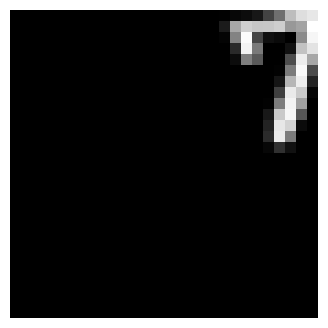

In [ ]:
#ver la image cargda
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(img_final[0, :, :, 0], cmap='gray')
plt.axis('off')
plt.show()

## Hacer la predicción



In [ ]:
# Load the trained model
modelo_cargado = tf.keras.models.load_model('numerosD1.keras')

# Make a prediction
predicciones = modelo_cargado.predict(img_final)

# Get the predicted class index
predicted_class_index = np.argmax(predicciones[0])

print(f"Predicted class probabilities: {predicciones[0]}")
print(f"Predicted digit: {predicted_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
Predicted class probabilities: [1.3833548e-16 8.4971751e-19 2.8205272e-19 1.1425460e-10 6.6891166e-15
 9.9999964e-01 4.2410488e-11 3.7661647e-15 3.6093826e-07 1.3805320e-12]
Predicted digit: 5


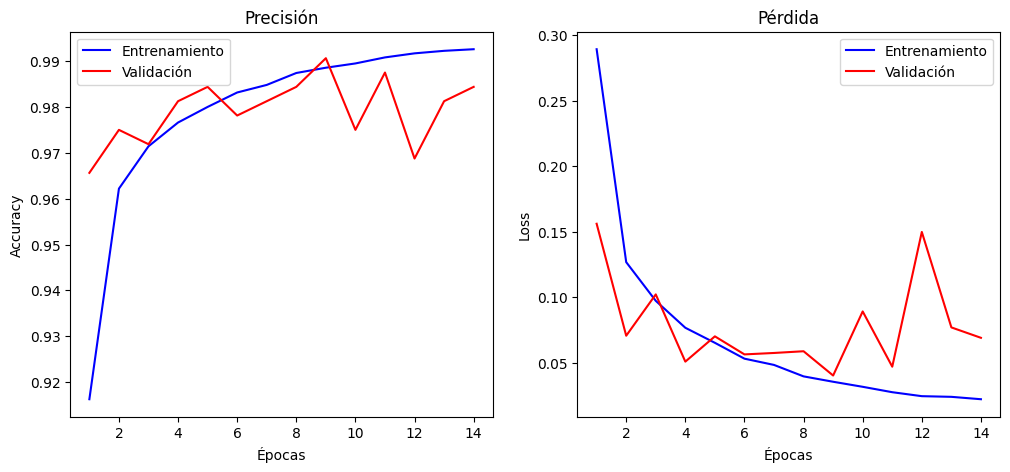

In [ ]:
# Extraer métricas del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

# Gráfica de precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento')
plt.plot(epocas, val_acc, 'r-', label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento')
plt.plot(epocas, val_loss, 'r-', label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()